# Spotify Analytics 

## Read in the DataFrame

In [3]:
import pandas as pd

df = pd.read_csv("./spotify.csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Central Tendency

In [4]:
mean = df['in_spotify_playlists'].mean()
median = df['in_spotify_playlists'].median()

# we can use the stats class from the scipy package
from scipy import stats
mode = stats.mode(df['in_spotify_playlists'])

print(f"Mean:   {mean}")
print(f"Median: {median}")
print(f"Mode:   {mode[0]}")

Mean:   5202.56512605042
Median: 2216.5
Mode:   86


## Boxplot Analysis

In order to do plotting, we need to import the `pyplot` class from the `matplotlib` module.

C:\Users\genes\AppData\Local\Temp\ipykernel_21128\3308289181.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['bpm'], vert=False)


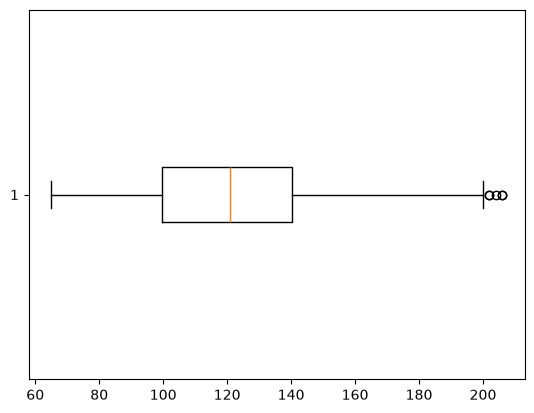

In [5]:
import matplotlib.pyplot as plt

plt.boxplot(df['bpm'], vert=False)
plt.show()

## Boxplot audio features

C:\Users\genes\AppData\Local\Temp\ipykernel_21128\1789521244.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot([df[f] for f in features], vert=False, tick_labels=features)


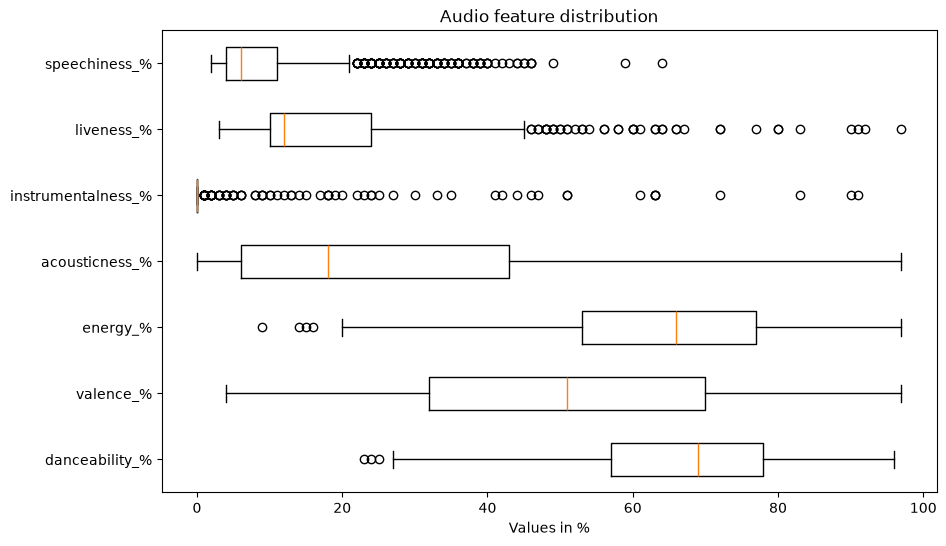

In [6]:
features = ['danceability_%', 'valence_%', 'energy_%','acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'  ]
plt.figure(figsize=(10,6))
plt.boxplot([df[f] for f in features], vert=False, tick_labels=features)
plt.title("Audio feature distribution")
plt.xlabel("Values in %")
plt.show()

## Interpret the results of the boxplot for the audio features. 

Speechiness has very low variance, seems to be skewed and has many outliers. Instrumentalness has no box in it. While valence seems to be a much more symmetric box plot.

## Display histogram for danceability and energy audio features

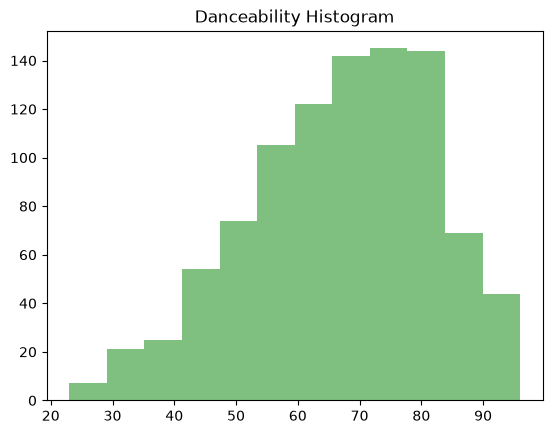

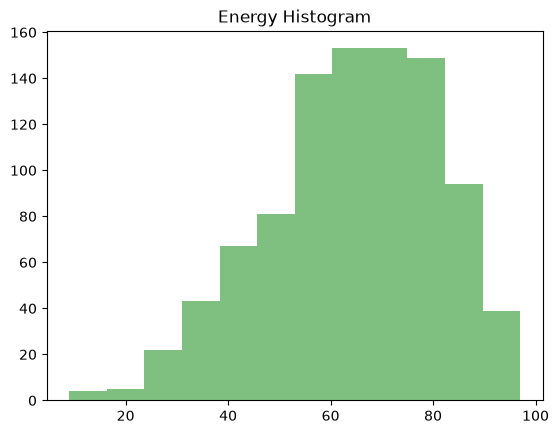

In [7]:
plt.hist(df['danceability_%'], bins=12, color='green', alpha=0.5)
plt.title("Danceability Histogram")
plt.show()

plt.hist(df['energy_%'], bins=12, color='green', alpha=0.5)
plt.title("Energy Histogram")
plt.show()


## Bonus task: Show how many songs were released each year based on the released_year feature.

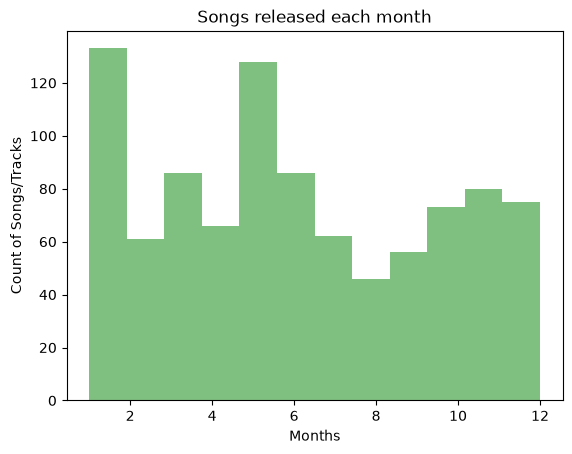

In [8]:
plt.hist(df['released_month'], bins=12, color='green', alpha=0.5)
plt.title("Songs released each month")
plt.xlabel("Months")
plt.ylabel("Count of Songs/Tracks")
plt.show()

## Bonus task: Show how many songs were released each year based on the released_year feature and display that in the histogram.


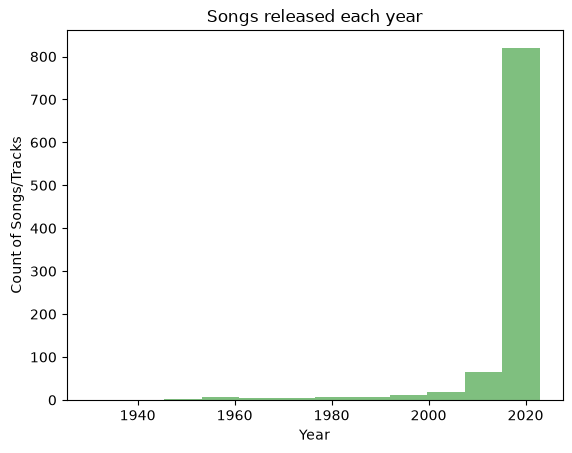

In [9]:
plt.hist(df['released_year'], bins=12, color='green', alpha=0.5)
plt.title("Songs released each year")
plt.xlabel("Year")
plt.ylabel("Count of Songs/Tracks")
plt.show()

# Five Number Summary (FNS)

I want the FNS of the `bpm` column.

- Min
- Lower quartile / Q1 (25%)
- Median / Q2 (50%)
- Upper quartile / Q3 (75%)
- Max

We can use the `numpy` package to calculate these values.

In [10]:
import numpy as np

min = np.min(df.bpm) # df.bpm is the same as df['bpm']
q1 = np.percentile(df.bpm, 25)
med = np.median(df.bpm)
q3 = np.percentile(df.bpm, 75)
max = np.max(df.bpm)

# we could do this on one line (see below)
# five_num_summary = np.percentile(df.bpm, [0, 25, 50, 75, 100])

print('------------ FNS -------------')
print(f"Min: {min}")
print(f"Q1: {q1}")
print(f"Median: {med}")
print(f"Q3: {q3}")
print(f"Max: {max}")



------------ FNS -------------
Min: 65
Q1: 99.75
Median: 121.0
Q3: 140.25
Max: 206


## FNS as a Function

In [11]:
def fns(column):
    min = np.min(df[column]) 
    q1 = np.percentile(df[column], 25)
    med = np.median(df[column])
    q3 = np.percentile(df[column], 75)
    max = np.max(df[column])

    print(f'------------ FNS for {column.capitalize()} -------------')
    print(f"Min: {min}")
    print(f"Q1: {q1}")
    print(f"Median: {med}")
    print(f"Q3: {q3}")
    print(f"Max: {max}")

fns('bpm')
fns('streams')
fns('released_year')

------------ FNS for Bpm -------------
Min: 65
Q1: 99.75
Median: 121.0
Q3: 140.25
Max: 206
------------ FNS for Streams -------------
Min: 2762
Q1: 141636175.0
Median: 290530915.0
Q3: 673869022.0
Max: 3703895074
------------ FNS for Released_year -------------
Min: 1930
Q1: 2020.0
Median: 2022.0
Q3: 2022.0
Max: 2023


## IQR, Outliers, Standard Deviation, and Variance

In [12]:
iqr = q3 - q1 # Interquartile range for bpm column
upper_limit = (1.5 * iqr) + q3
lower_limit = q1 - (1.5 * iqr)

print(f"Interquartile Range: {iqr}")
print(f"Upper Limit:         {upper_limit}")
print(f"Lower Limit:         {lower_limit}")

standard_dev = df['bpm'].std()
print()
print(f"Standard Deviation:  {standard_dev:.2f}")

variance = standard_dev ** 2 # x ** y is the same as 'x to the power of y'
print(f"Variance:            {variance:.2f}")

Interquartile Range: 40.5
Upper Limit:         201.0
Lower Limit:         39.0

Standard Deviation:  28.07
Variance:            787.90


## Histogram

I want a histogram for the `released_month` column.

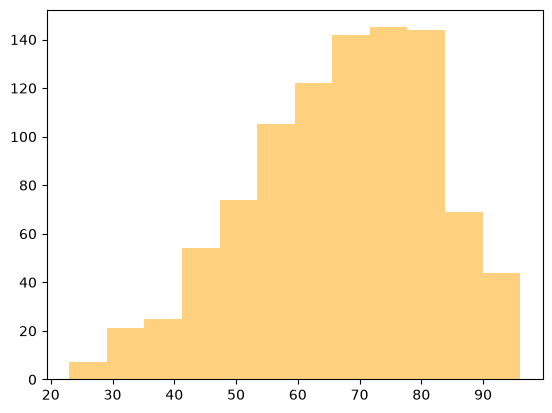

In [13]:
import matplotlib.pyplot as plt
plt.hist(df['danceability_%'], bins=12, color='orange', alpha=0.5)
plt.show()

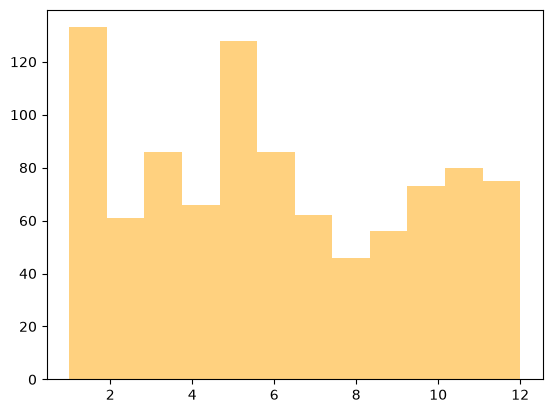

In [14]:
plt.hist(df['released_month'], bins=12, color='orange', alpha=0.5)
plt.show()

## Scatter Plot

I want a scatter plot to compare `streams` and `in_spotify_playlists`.

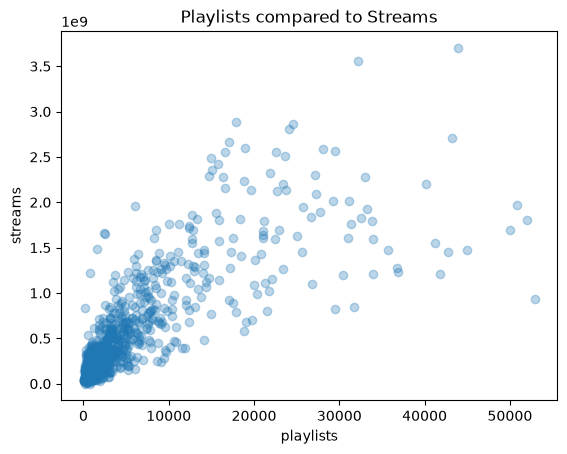

In [15]:
plt.scatter(x=df['in_spotify_playlists'], y = df['streams'], alpha=0.3)
plt.title("Playlists compared to Streams")
plt.xlabel('playlists')
plt.ylabel("streams")
plt.show()

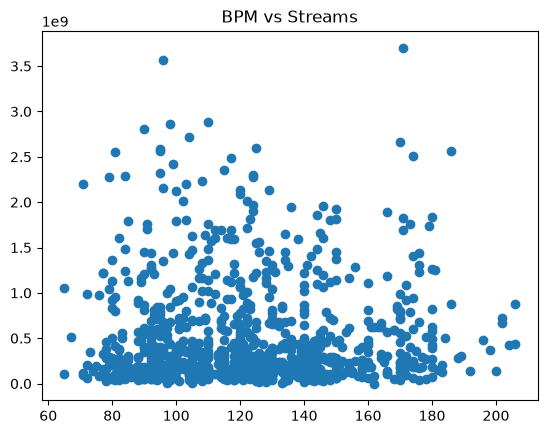

In [16]:
plt.scatter(x = df['bpm'], y = df['streams'])
plt.title("BPM vs Streams")
plt.show()

